In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import shutil

# Specify the source and destination paths
source_path = "Appliances.jsonl"  # Replace with the actual file name
destination_path = "/content/drive/My Drive/Appliances.jsonl"  # Save to your Google Drive

# Copy the file to Google Drive
shutil.copy(source_path, destination_path)

print(f"File saved to {destination_path}")


File saved to /content/drive/My Drive/Appliances.jsonl


In [ ]:
import json
file_path = "Appliances.jsonl"

# Read the file
data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line.strip()))

print(data[0])

{'rating': 5.0, 'title': 'Work great', 'text': 'work great. use a new one every month', 'images': [], 'asin': 'B01N0TQ0OH', 'parent_asin': 'B01N0TQ0OH', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1519317108692, 'helpful_vote': 0, 'verified_purchase': True}


In [ ]:
import pandas as pd

df = pd.DataFrame(data)
print(df.head())  # View the first few rows

   rating              title  \
0     5.0         Work great   
1     5.0  excellent product   
2     5.0    Happy customer!   
3     5.0      Amazing value   
4     5.0        Dryer parts   

                                                text images        asin  \
0              work great. use a new one every month     []  B01N0TQ0OH   
1                            Little on the thin side     []  B07DD2DMXB   
2                   Quick delivery, fixed the issue!     []  B082W3Z9YK   
3  I wasn't sure whether these were worth it or n...     []  B078W2BJY8   
4  Easy to install got the product expected to re...     []  B08C9LPCQV   

  parent_asin                       user_id      timestamp  helpful_vote  \
0  B01N0TQ0OH  AGKHLEW2SOWHNMFQIJGBECAF7INQ  1519317108692             0   
1  B07DD37QPZ  AHWWLSPCJMALVHDDVSUGICL6RUCA  1664746863446             0   
2  B082W3Z9YK  AHZIJGKEWRTAEOZ673G5B3SNXEGQ  1607225435363             0   
3  B078W2BJY8  AFGUPTDFAWOHHL4LZDV27ERDNOYQ  1534104

## Filtering the reviews with images only

In [ ]:
print(df['images'].astype(str).unique())

['[]'
 "[{'small_image_url': 'https://m.media-amazon.com/images/I/71nm+GrlAOL._SL256_.jpg', 'medium_image_url': 'https://m.media-amazon.com/images/I/71nm+GrlAOL._SL800_.jpg', 'large_image_url': 'https://m.media-amazon.com/images/I/71nm+GrlAOL._SL1600_.jpg', 'attachment_type': 'IMAGE'}]"
 "[{'small_image_url': 'https://m.media-amazon.com/images/I/61xDBuHT1RL._SL256_.jpg', 'medium_image_url': 'https://m.media-amazon.com/images/I/61xDBuHT1RL._SL800_.jpg', 'large_image_url': 'https://m.media-amazon.com/images/I/61xDBuHT1RL._SL1600_.jpg', 'attachment_type': 'IMAGE'}]"
 ...
 "[{'small_image_url': 'https://m.media-amazon.com/images/I/31xA6t0m4uL._SL256_.jpg', 'medium_image_url': 'https://m.media-amazon.com/images/I/31xA6t0m4uL._SL800_.jpg', 'large_image_url': 'https://m.media-amazon.com/images/I/31xA6t0m4uL._SL1600_.jpg', 'attachment_type': 'IMAGE'}]"
 "[{'small_image_url': 'https://m.media-amazon.com/images/I/61f+9k+xKNL._SL256_.jpg', 'medium_image_url': 'https://m.media-amazon.com/images/I/

In [ ]:
# image_df contains reviews with image only
image_df=df[df['images'].astype(str)!='[]']
image_df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
97,5.0,Excellent!,I work in a bookstore and so these little gadg...,[{'small_image_url': 'https://m.media-amazon.c...,B07QC7JRDP,B07QC7JRDP,AEHWUHNTB5FX32HJ7UBOZ2WWUX3Q,1652793036100,0,True
153,1.0,"HIGHLY, HIGHLY OVERPRICED","wow, is this a rip off or what? after I cleane...",[{'small_image_url': 'https://m.media-amazon.c...,B0882ZJ48W,B0882ZJ48W,AGUWL2R2JFLC3K65HLD6AHJV3KBA,1639713939756,0,True
178,4.0,Works fine like every other filter I tried pre...,There are 40 #4 cone coffee filters in this pa...,[{'small_image_url': 'https://images-na.ssl-im...,B08F9VXZBM,B08F9VXZBM,AFXF3EGQTQDXMRLDWFU7UBFQZB7Q,1624554564327,1,False
189,5.0,Love everything about Nespresso except pod $..!!,01/23 update: trying a different brand of lids...,[{'small_image_url': 'https://m.media-amazon.c...,B09W3YPC6N,B09W3YPC6N,AEIPJBAN7A55Q5DFFPZSR2UV3OKA,1661158891125,20,False
208,5.0,Christmas Gift,My niece loved these!,[{'small_image_url': 'https://m.media-amazon.c...,B0B9J6P1PQ,B0B9J4TVR8,AGTFULIOVJK6RHUYWETEGSE5ITCQ,1674510434866,0,True


In [ ]:
image_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84949 entries, 97 to 2128580
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             84949 non-null  float64
 1   title              84949 non-null  object 
 2   text               84949 non-null  object 
 3   images             84949 non-null  object 
 4   asin               84949 non-null  object 
 5   parent_asin        84949 non-null  object 
 6   user_id            84949 non-null  object 
 7   timestamp          84949 non-null  int64  
 8   helpful_vote       84949 non-null  int64  
 9   verified_purchase  84949 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 6.6+ MB


In [ ]:
image_df.to_csv('image_df.csv', index=False)

## Comparing rating distribution on whole dataset & the image dataset

In [ ]:
image_df['title'].groupby(image_df['rating']).count()/84949

,title
rating,
1.0,0.244276
2.0,0.061590
3.0,0.065133
4.0,0.100131
5.0,0.528870


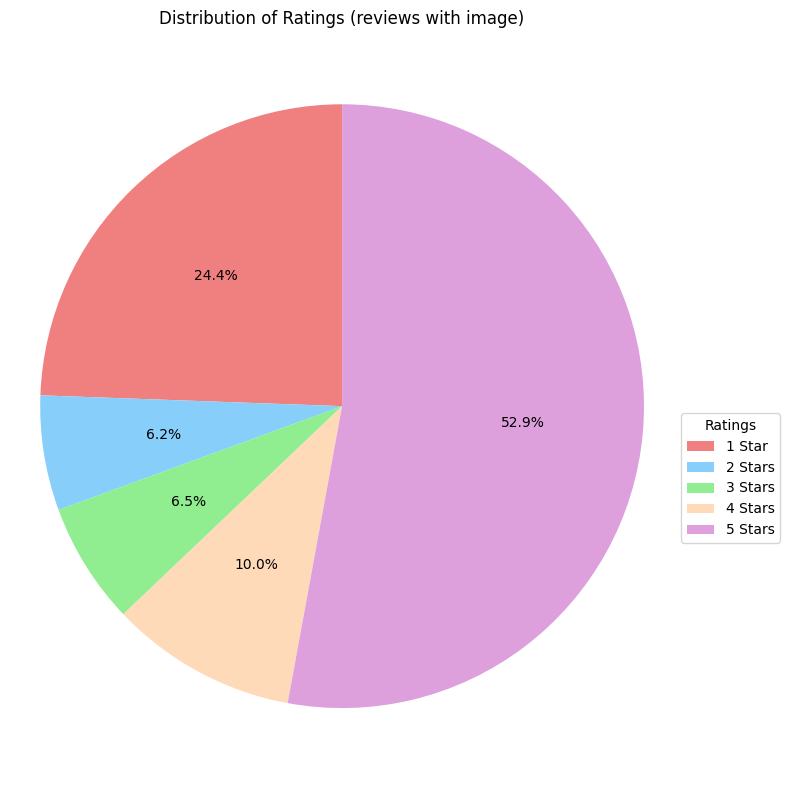

In [ ]:
import matplotlib.pyplot as plt

# Given rating percentages
ratings = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']
percentages = [0.244276, 0.061590, 0.065133, 0.100131, 0.528870]

# Convert percentages to actual percentages for display
percentages = [p * 100 for p in percentages]

# Define lighter custom colors for the ratings
colors = ['lightcoral', 'lightskyblue', 'lightgreen', 'peachpuff', 'plum']

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    percentages,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

# Add a legend outside the pie chart
plt.legend(
    labels=[f"{rating}" for rating in ratings],
    loc="upper left",
    bbox_to_anchor=(1, 0.5),  # Moves legend outside the chart
    title="Ratings"
)

# Add a title and show the chart
plt.title('Distribution of Ratings (reviews with image)')
plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle
plt.tight_layout()
plt.show()



In [ ]:
df['title'].groupby(df['rating']).count()/2128605

,title
rating,
1.0,0.117661
2.0,0.037425
3.0,0.048880
4.0,0.097818
5.0,0.698215


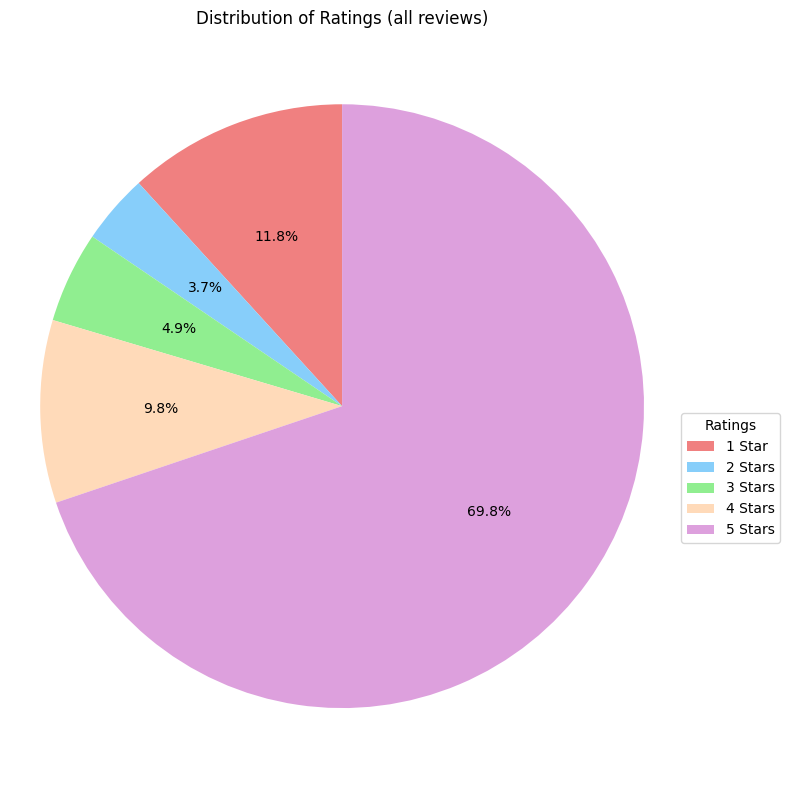

In [ ]:
ratings = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']
percentages = [0.117661, 0.037425, 0.048880, 0.097818, 0.698215]

# Convert percentages to actual percentages for display
percentages = [p * 100 for p in percentages]

# Define lighter custom colors for the ratings
colors = ['lightcoral', 'lightskyblue', 'lightgreen', 'peachpuff', 'plum']

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    percentages,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

# Add a legend outside the pie chart
plt.legend(
    labels=[f"{rating}" for rating in ratings],
    loc="upper left",
    bbox_to_anchor=(1, 0.5),  # Moves legend outside the chart
    title="Ratings"
)

# Add a title and show the chart
plt.title('Distribution of Ratings (all reviews)')
plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle
plt.tight_layout()
plt.show()